In [1]:
import torch
import matplotlib.pyplot as plt
from math import ceil
from skimage.morphology import skeletonize
from definitions import (
    modulo
)
import cv2
import numpy as np
import torch.nn.functional as F

test = False

if not test:
    shifts = [0]
else:
    shifts = [0]

index = 4

## Definitions

In [2]:
def perfect_lift(points, No, sigma=1.0):    
    points = points.float()
    radius = int(torch.ceil(torch.tensor(3.0 * sigma)).item())
    points_yx = points[:,[1,0]]
    
    points_e = torch.cat((points_yx, points_yx[0, None]), dim=0)
    v = points_e[1:] - points_e[:-1]  
    
    x = torch.arange(-radius, radius + 1)
    kernel = torch.exp(-x**2 / (2 * sigma**2))
    kernel = kernel / kernel.sum()  
    kernel = kernel.view(1, 1, -1).repeat(2, 1, 1)
        
    # v has shape (N,2) --> v_tensor has shape (1, 2, N)
    v_tensor = v.t()[None]
    # convolution with Gaussian for y and x seperately    
    v_padded = F.pad(v_tensor, (radius, radius), mode='circular')
    v_smoothed_tensor = F.conv1d(v_padded, kernel, padding=0, groups=2)
    
    v_smoothed = v_smoothed_tensor[0].t()
          
    orientation = modulo(
        torch.round(torch.arctan2(v_smoothed[:, 0], v_smoothed[:, 1]) * No / (2 * torch.pi)), 
        No
    ) * ((2 * torch.pi) / No)
   
    return torch.cat((orientation[:, None], points_e[:-1:]), dim=1)

def make_image_lift(perfectlift, No, f):
    lift = torch.zeros(No, f.shape[1], f.shape[0])
    lift[(perfectlift[:, 0]*No / (2 * torch.pi)).to(torch.int64), perfectlift[:, 1].to(torch.int64), perfectlift[:, 2].to(torch.int64)] = 1
    #lift[modulo(perfectlift[:, 0]+ No/2, No).to(torch.int64), perfectlift[:, 1].to(torch.int64), perfectlift[:, 2].to(torch.int64)] = 1
    return lift

# Lines

synthetic data

In [3]:
def get_projected_data(shft):
    data = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/connected_components.pt")  #_{shft}
    return [torch.max(d, dim=-3).values for d in data]

def get_projected_data_test(index):
    data = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/connected_components_test_{index}.pt") 
    return [torch.max(d, dim=-3).values for d in data]

In [4]:
for shft in shifts:
    if not test:
        #synthetic
        projected_data = get_projected_data(shft)

        contours = []

        proj_numpy = [np.uint8(((proj>0.8)*1).cpu()) for proj in projected_data]

        for image in proj_numpy:
            contours_per_image = []
            for component in image:
                contour, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                if len(contour) == 0 or len(contour) > 1:
                    print(image, component)
                    raise ValueError("Bad!")
                contours_per_image.append(contour)
            contours.append(contours_per_image)

        No = 12

        # flip --> for contour clockwise rotation
        lifted_contours = [[perfect_lift(torch.tensor(per_comp).squeeze(dim=(0, 2)).flip(0), No) for per_comp in per_image] for per_image in contours]
        lifted_contours_volume = [[make_image_lift(per_comp, No, projected_data[i][j]) for j, per_comp in enumerate(per_image)] for i, per_image in enumerate(lifted_contours)] 

        # torch.save(lifted_contours, f"lifted_contours.pt") 
    else:
        #experimental
        projected_data = get_projected_data_test(index)

        contours = []

        proj_numpy = [np.uint8(((proj>0.8)*1).cpu()) for proj in projected_data]

        for image in proj_numpy:
            contours_per_image = []
            for component in image:
                contour, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                if len(contour) == 0 or len(contour) > 1:
                    print(image, component)
                    raise ValueError("Bad!")
                contours_per_image.append(contour)
            contours.append(contours_per_image)

        No = 12

        # flip --> for contour clockwise rotation
        lifted_contours = [[perfect_lift(torch.tensor(per_comp).squeeze(dim=(0, 2)).flip(0), No) for per_comp in per_image] for per_image in contours]
        lifted_contours_volume = [[make_image_lift(per_comp, No, projected_data[i][j]) for j, per_comp in enumerate(per_image)] for i, per_image in enumerate(lifted_contours)] 

        # torch.save(lifted_contours, f"lifted_contours_test_{index}.pt")

C:\Users\levis\AppData\Local\Temp\ipykernel_31052\1189897510.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  lifted_contours = [[perfect_lift(torch.tensor(per_comp).squeeze(dim=(0, 2)).flip(0), No) for per_comp in per_image] for per_image in contours]


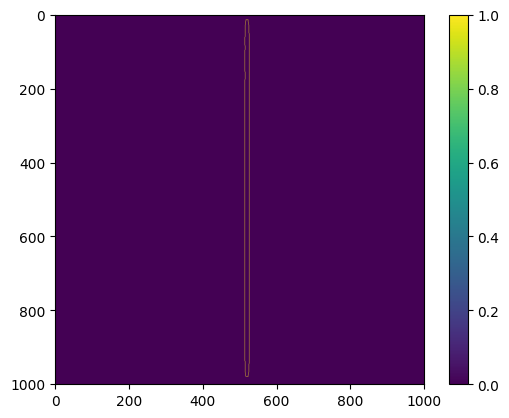

In [5]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(torch.max(lifted_contours_volume[0][10], dim=0)[0])
fig.colorbar(cbar, ax=ax)

# Blobs

In [6]:
def get_projected_data(shft):
    data = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/connected_components_blobs.pt") # _{shft}
    return data

def get_projected_data_test(index):
    data = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/connected_components_blobs_test_{index}.pt") 
    return data

In [ ]:
for shft in shifts:
    if not test:
        #synthetic
        projected_data = get_projected_data(shft)

        contours = []

        proj_numpy = [np.uint8(((proj>0.8)*1).cpu()) for proj in projected_data]

        for j,image in enumerate(proj_numpy):
            contours_per_image = []
            for i,component in enumerate(image):
                contour, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                if len(contour) == 0 or len(contour) > 1: 
                    print(len(contour), i,j ,contour)
                    raise ValueError("Bad!")
                contours_per_image.append(contour)
            contours.append(contours_per_image)

            No = 12
            lifted_contours = [[perfect_lift(torch.tensor(per_comp).squeeze(dim=(0, 2)).flip(0), No) for per_comp in per_image] for per_image in contours]
            # torch.save(lifted_contours, f"lifted_contours_blobs.pt") 
    else: 
        #experimental
        projected_data = get_projected_data_test(index)

        contours = []

        proj_numpy = [np.uint8(((proj>0.8)*1).cpu()) for proj in projected_data]

        for j,image in enumerate(proj_numpy):
            contours_per_image = []
            for i,component in enumerate(image):
                contour, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                if len(contour) == 0 or len(contour) > 1: 
                    print(len(contour), i,j ,contour)
                    raise ValueError("Bad!")
                contours_per_image.append(contour)
            contours.append(contours_per_image)

        No = 12
        lifted_contours = [[perfect_lift(torch.tensor(per_comp).squeeze(dim=(0, 2)).flip(0), No) for per_comp in per_image] for per_image in contours]
        # torch.save(lifted_contours, f"lifted_contours_blobs_test_{index}.pt")


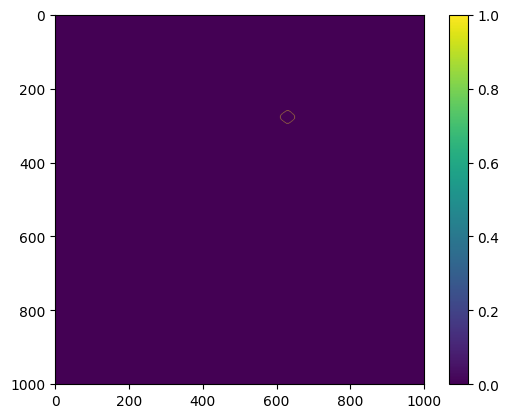

In [ ]:
lifted_contours_volume = [[make_image_lift(per_comp, No, projected_data[i][j]) for j, per_comp in enumerate(per_image[100:101])] for i, per_image in enumerate(lifted_contours)] 
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(torch.max(lifted_contours_volume[0][0], dim=0)[0])
fig.colorbar(cbar, ax=ax)